<a href="https://colab.research.google.com/github/allatop/networks/blob/main/_____9_____yolov12___________.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №9. Использование модели YOLOv26 для решение задач детекции и классификации**

## **Задание 1. Знакомство с новейшей версией модели YOLO**

- Ознакомьтесь с технической документацией по новейшей версии модели YOLOv26: https://docs.ultralytics.com/ru/models/yolo26/

- Рассмотрите пример обучения этой модели c использованием датасетов, созданных в Roboflow: https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/train-yolo26-object-detection-on-custom-dataset.ipynb?ref=blog.roboflow.com

### **Ответьте на вопрос: Какие принципиальные отличия появились в модели YOLOv26 относительно предыдущих версий?**

**ВАШ ОТВЕТ**

*Примечание:* для каждого последующего задания, в конечном итоге, необходимо сформировать обученную модель и задеплоить её на сервисе **RoboFlow**



## **Задание 2. Найдите готовый датасет для детекции объектов и обучите на нем модель YOLOv26:**

- Для удобства работы с датасетом и деплоя модели используйте сервис [RoboFlow](https://roboflow.com/)

In [ ]:
!pip install -U ultralytics roboflow

from ultralytics import YOLO
from roboflow import Roboflow

ROBOFLOW_API_KEY = "6pt5axvTvTZ4RzioQpWq"

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("fish-zys89").project("aquarium-1pzh8")
dataset = project.version(1).download("yolov8")

model = YOLO("yolo26n.pt")

results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    device=0
)

metrics = model.val(data=f"{dataset.location}/data.yaml")
print(f"mAP@50-95: {metrics.box.map:.3f}")

model.export(format="onnx", imgsz=640)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 103.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings w


Extracting Dataset Version Zip to Aquarium-1 in yolov8:: 100%|██████████| 1286/1286 [00:00<00:00, 8848.16it/s]


Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Aquarium-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, pe

Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.


ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 11.7s, saved as '/content/runs/detect/train/weights/best.onnx' (9.4 MB)

Export complete (12.0s)
Results saved to /content/runs/detect/train/weights
Predict:         yolo predict task=detect model=/content/runs/detect/train/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/runs/detect/train/weights/best.onnx imgsz=640 data=/content/Aquarium-1/data.yaml  
Visualize:       https://netron.app


'/content/runs/detect/train/weights/best.onnx'


image 1/1 /content/Aquarium-1/valid/images/IMG_8582_MOV-5_jpg.rf.1d27466d76df85a54c253c59443391b0.jpg: 640x640 6 fishs, 25.8ms
Speed: 9.2ms preprocess, 25.8ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


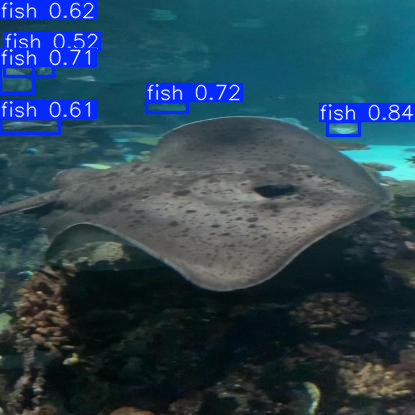


image 1/1 /content/Aquarium-1/valid/images/IMG_2434_jpeg_jpg.rf.d2c465cd07775d42427f5d1ef94c7777.jpg: 640x640 5 fishs, 1 shark, 19.8ms
Speed: 3.3ms preprocess, 19.8ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


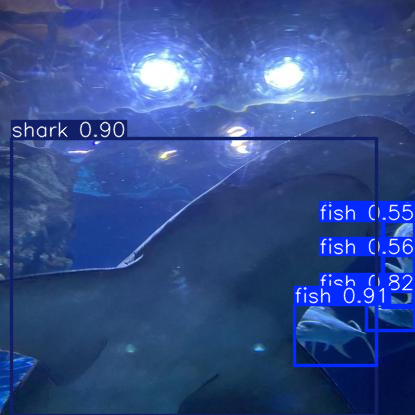


image 1/1 /content/Aquarium-1/valid/images/IMG_2491_jpeg_jpg.rf.501ba73dab4a81c1f330ac55c85be78d.jpg: 640x640 5 jellyfishs, 23.1ms
Speed: 4.3ms preprocess, 23.1ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)


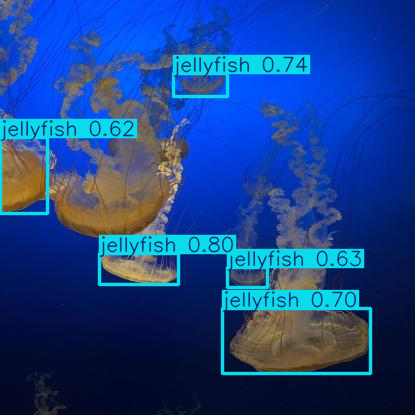

In [ ]:
from ultralytics import YOLO
import random
import glob
from PIL import Image
import cv2
from IPython.display import display

model = YOLO('/content/runs/detect/train/weights/best.pt')

val_images = glob.glob('/content/Aquarium-1/valid/images/*.jpg')
sample_images = random.sample(val_images, 3)

for img_path in sample_images:
    results = model.predict(source=img_path, conf=0.35)

    res_image_array = results[0].plot()
    res_image_rgb = cv2.cvtColor(res_image_array, cv2.COLOR_BGR2RGB)

    display(Image.fromarray(res_image_rgb))

## **Задание 3. Сформируйте свой датасет для детекции объектов и обучите на нем модель YOLOv26**



Требования к датасету:

- Количество изображений в датасете: минимум 90
- Количество классов: более 2х
- Обязательно должны присутствовать изображения, содержащие несколько классов одновременно


*Примечание: Формирование датасета включает в себя поиск изображений и ручное аннотирование объектов на изображениях.*

In [ ]:


from ultralytics import YOLO
from roboflow import Roboflow

rf = Roboflow(api_key="6pt5axvTvTZ4RzioQpWq")
project = rf.workspace("new-workspace-xn4bg").project("cat-tweny")
version = project.version(2)
dataset = version.download("yolov8")

model = YOLO("yolo26n.pt")


results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=100,
    imgsz=500,
    batch=16,
    patience=25,
    device=0
)

metrics = model.val(data=f"{dataset.location}/data.yaml")
print(f"Итоговая точность mAP@50-95: {metrics.box.map:.3f}")

model.export(format="onnx", imgsz=500)

loading Roboflow workspace...
loading Roboflow project...
Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/cat-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=500, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-5, nbs=64, nms=False, opset=None, optimize=Fa

Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.


ONNX: export success ✅ 1.7s, saved as '/content/runs/detect/train-5/weights/best.onnx' (9.3 MB)

Export complete (2.0s)
Results saved to /content/runs/detect/train-5/weights
Predict:         yolo predict task=detect model=/content/runs/detect/train-5/weights/best.onnx imgsz=512 
Validate:        yolo val task=detect model=/content/runs/detect/train-5/weights/best.onnx imgsz=512 data=/content/cat-2/data.yaml  
Visualize:       https://netron.app


'/content/runs/detect/train-5/weights/best.onnx'


image 1/1 /content/cat-2/valid/images/ac239f54b50d70003a1e06c6785c4674_jpg.rf.3a0568db87a2bd343a54482d2bcbaeda.jpg: 512x512 1 dog, 5 horses, 12.8ms
Speed: 1.6ms preprocess, 12.8ms inference, 0.4ms postprocess per image at shape (1, 3, 512, 512)


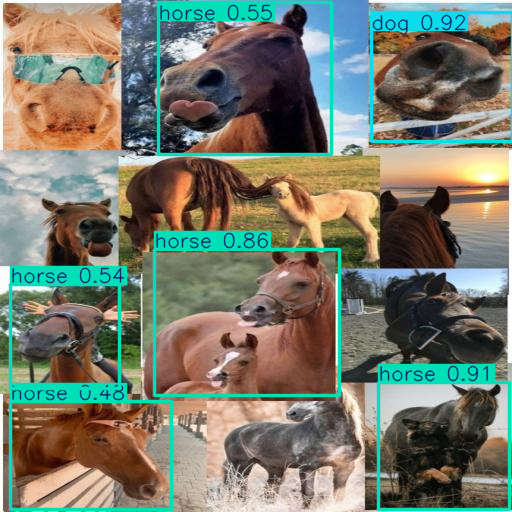


image 1/1 /content/cat-2/valid/images/C8_jpg.rf.3c7a191b2a8deea7e26588b5b8c777c0.jpg: 512x512 1 Cat, 17.7ms
Speed: 2.7ms preprocess, 17.7ms inference, 0.6ms postprocess per image at shape (1, 3, 512, 512)


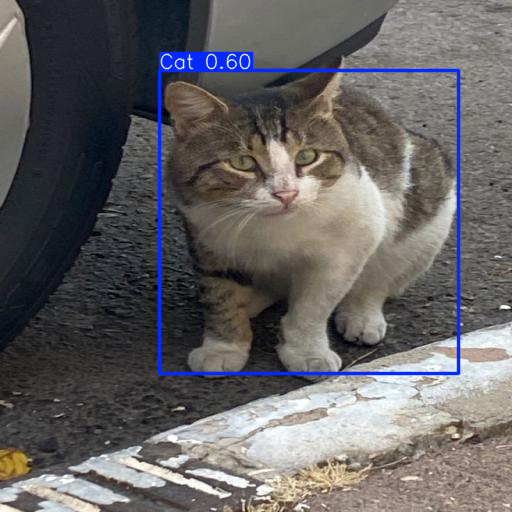


image 1/1 /content/cat-2/valid/images/C14_jpg.rf.2ec21855fb528f62214230bed70190ba.jpg: 512x512 1 Cat, 19.2ms
Speed: 1.6ms preprocess, 19.2ms inference, 0.6ms postprocess per image at shape (1, 3, 512, 512)


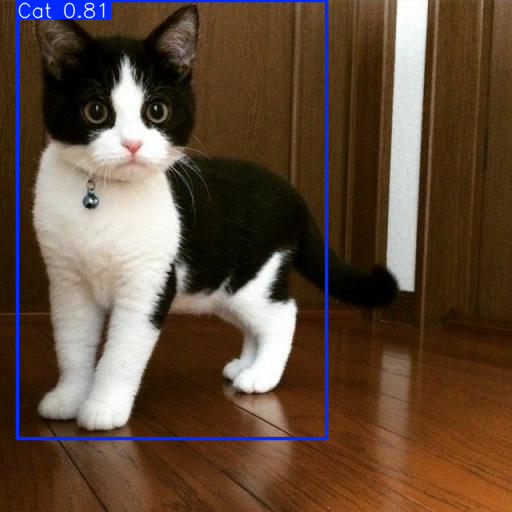

In [ ]:


from ultralytics import YOLO
import random
import glob
from PIL import Image
import cv2
from IPython.display import display

model = YOLO('/content/runs/detect/train-5/weights/best.pt')

val_images = glob.glob('/content/cat-2/valid/images/*.jpg')
sample_images = random.sample(val_images, 3)

for img_path in sample_images:
    results = model.predict(source=img_path, conf=0.35)

    res_image_array = results[0].plot()
    res_image_rgb = cv2.cvtColor(res_image_array, cv2.COLOR_BGR2RGB)

    display(Image.fromarray(res_image_rgb))